In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
sales_df = pd.read_csv(
    "../Dataset/clean_retail.csv"
)

In [5]:
sales_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Day
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,1


In [6]:
sales_df["InvoiceDate"] = pd.to_datetime(
    sales_df["InvoiceDate"]
)

In [7]:
sales_df["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

In [8]:
snapshot_date = (
    sales_df["InvoiceDate"].max()
    +
    pd.Timedelta(days=1)
)

snapshot_date

Timestamp('2011-12-10 12:50:00')

In [9]:
recency = sales_df.groupby(
    "Customer ID"
)["InvoiceDate"].max()

In [10]:
recency = (
    snapshot_date
    -
    recency
).dt.days

In [11]:
recency.head()

Customer ID
12346.0    326
12347.0      2
12348.0     75
12349.0     19
12350.0    310
Name: InvoiceDate, dtype: int64

In [12]:
frequency = sales_df.groupby(
    "Customer ID"
)["Invoice"].nunique()

In [13]:
frequency.head()

Customer ID
12346.0    12
12347.0     8
12348.0     5
12349.0     4
12350.0     1
Name: Invoice, dtype: int64

In [14]:
monetary = sales_df.groupby(
    "Customer ID"
)["Revenue"].sum()

In [15]:
monetary.head()

Customer ID
12346.0    77556.46
12347.0     4921.53
12348.0     2019.40
12349.0     4428.69
12350.0      334.40
Name: Revenue, dtype: float64

In [16]:
rfm = pd.DataFrame({
    "Recency": recency,
    "Frequency": frequency,
    "Monetary": monetary
})

In [17]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,4921.53
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [18]:
rfm.to_csv(
    "../Dataset/rfm_table.csv"
)

In [19]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
)

In [20]:
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

In [21]:
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
)

In [22]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    +
    rfm["F_Score"].astype(str)
    +
    rfm["M_Score"].astype(str)
)

In [23]:
rfm["Segment"] = "Regular"

In [24]:
rfm.loc[
    (
        rfm["R_Score"] >= 4
    )
    &
    (
        rfm["F_Score"] >= 4
    )
    &
    (
        rfm["M_Score"] >= 4
    ),
    "Segment"
] = "VIP"

In [25]:
rfm.loc[
    (
        rfm["R_Score"] <= 2
    )
    &
    (
        rfm["Frequency"] > rfm["Frequency"].median()
    ),
    "Segment"
] = "At Risk"

In [26]:
rfm["Segment"].value_counts()

Segment
Regular    3299
At Risk    2519
VIP          60
Name: count, dtype: int64

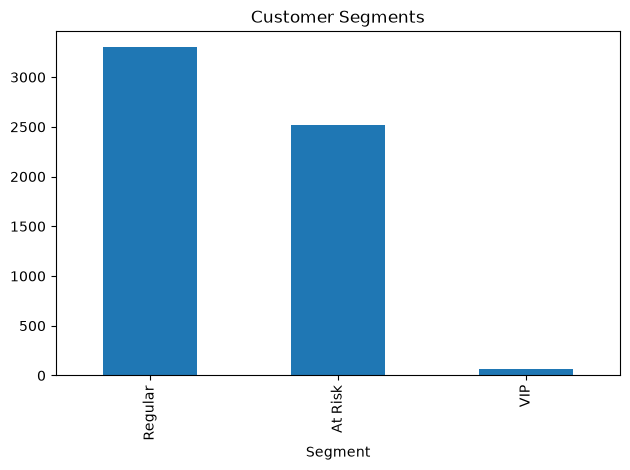

In [27]:
rfm["Segment"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Customer Segments"
)

plt.tight_layout()

plt.savefig(
    "../Images/rfm_segments.png"
)

plt.show()

In [28]:
rfm.sort_values(
    "Monetary",
    ascending=False
).head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
Customer ID,,,,,,,,
18102.0,1,145,580987.04,5,5,5,555,At Risk
14646.0,2,151,528602.52,5,5,5,555,At Risk
14156.0,10,156,313437.62,5,5,5,555,At Risk
14911.0,1,398,291420.81,5,5,5,555,At Risk
17450.0,8,51,244784.25,5,5,5,555,At Risk
13694.0,4,143,195640.69,5,5,5,555,At Risk
17511.0,3,60,172132.87,5,5,5,555,At Risk
16446.0,1,2,168472.50,5,2,5,525,Regular
16684.0,4,55,147142.77,5,5,5,555,At Risk


In [27]:
rfm[
    rfm["RFM_Score"] == "555"
].head(20)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
Customer ID,,,,,,,,
12362.0,3,11,5356.23,5,5,5,555,At Risk
12395.0,19,15,4721.17,5,5,5,555,At Risk
12417.0,3,20,6797.41,5,5,5,555,At Risk
12433.0,1,10,16794.14,5,5,5,555,At Risk
12437.0,2,39,12683.40,5,5,5,555,At Risk
12471.0,2,79,39918.19,5,5,5,555,At Risk
12474.0,17,31,12372.75,5,5,5,555,At Risk
12476.0,16,23,14083.91,5,5,5,555,At Risk
12483.0,17,19,5097.18,5,5,5,555,At Risk


In [29]:
rfm["Segment"].value_counts()

Segment
Regular    3299
At Risk    2519
VIP          60
Name: count, dtype: int64

In [30]:
rfm["Segment"] = "Regular"

# VIP Customers

rfm.loc[
    (
        rfm["R_Score"].astype(int) >= 4
    )
    &
    (
        rfm["F_Score"].astype(int) >= 4
    )
    &
    (
        rfm["M_Score"].astype(int) >= 4
    ),
    "Segment"
] = "VIP"

# At Risk Customers

rfm.loc[
    (
        rfm["R_Score"].astype(int) <= 2
    )
    &
    (
        rfm["Frequency"] >
        rfm["Frequency"].median()
    ),
    "Segment"
] = "At Risk"

In [31]:
rfm[
    rfm["RFM_Score"] == "555"
].head(20)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
Customer ID,,,,,,,,
12362.0,3,11,5356.23,5,5,5,555,VIP
12395.0,19,15,4721.17,5,5,5,555,VIP
12417.0,3,20,6797.41,5,5,5,555,VIP
12433.0,1,10,16794.14,5,5,5,555,VIP
12437.0,2,39,12683.40,5,5,5,555,VIP
12471.0,2,79,39918.19,5,5,5,555,VIP
12474.0,17,31,12372.75,5,5,5,555,VIP
12476.0,16,23,14083.91,5,5,5,555,VIP
12483.0,17,19,5097.18,5,5,5,555,VIP


In [32]:
rfm["Segment"].value_counts()

Segment
Regular    4126
VIP        1297
At Risk     455
Name: count, dtype: int64

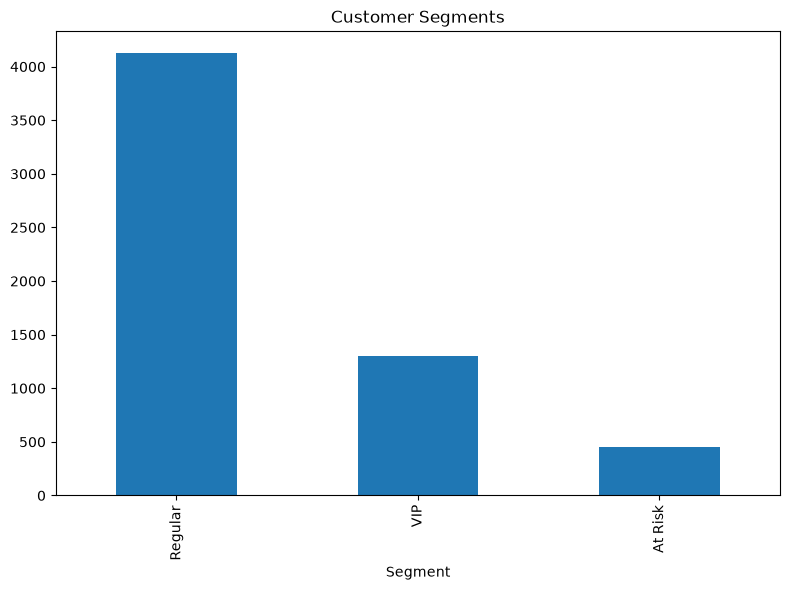

In [32]:
plt.figure(figsize=(8,6))

rfm["Segment"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Customer Segments"
)

plt.tight_layout()

plt.savefig(
    "../Images/rfm_segments.png"
)

plt.show()

In [33]:
vip_customers = rfm[
    rfm["Segment"] == "VIP"
]

vip_customers.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
Customer ID,,,,,,,,
12347.0,2,8,4921.53,5,4,5,545,VIP
12352.0,36,10,2849.84,4,5,4,454,VIP
12356.0,23,6,6371.73,4,4,5,445,VIP
12358.0,2,5,3887.07,5,4,5,545,VIP
12359.0,58,10,8873.39,4,5,5,455,VIP


In [38]:
top_vip = vip_customers.sort_values(
    "Monetary",
    ascending=False
).head(10)

top_vip

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
Customer ID,,,,,,,,
18102.0,1,145,580987.04,5,5,5,555,VIP
14646.0,2,151,528602.52,5,5,5,555,VIP
14156.0,10,156,313437.62,5,5,5,555,VIP
14911.0,1,398,291420.81,5,5,5,555,VIP
17450.0,8,51,244784.25,5,5,5,555,VIP
13694.0,4,143,195640.69,5,5,5,555,VIP
17511.0,3,60,172132.87,5,5,5,555,VIP
16684.0,4,55,147142.77,5,5,5,555,VIP
12415.0,24,28,144458.37,4,5,5,455,VIP


In [39]:
top_vip.to_csv(
    "../Dataset/top_vip_customers.csv"
)

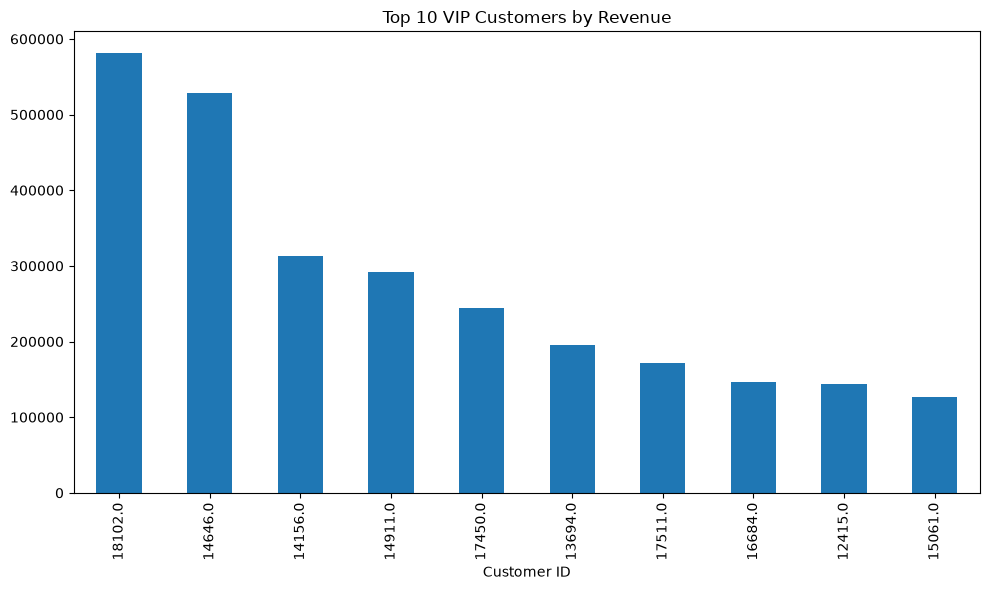

In [40]:
plt.figure(figsize=(10,6))

top_vip["Monetary"].plot(
    kind="bar"
)

plt.title(
    "Top 10 VIP Customers by Revenue"
)

plt.tight_layout()

plt.savefig(
    "../Images/top_vip_customers.png"
)

plt.show()

In [41]:
top_vip.head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
Customer ID,,,,,,,,
18102.0,1,145,580987.04,5,5,5,555,VIP
14646.0,2,151,528602.52,5,5,5,555,VIP
14156.0,10,156,313437.62,5,5,5,555,VIP
14911.0,1,398,291420.81,5,5,5,555,VIP
17450.0,8,51,244784.25,5,5,5,555,VIP
13694.0,4,143,195640.69,5,5,5,555,VIP
17511.0,3,60,172132.87,5,5,5,555,VIP
16684.0,4,55,147142.77,5,5,5,555,VIP
12415.0,24,28,144458.37,4,5,5,455,VIP


In [42]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
Customer ID,,,,,,,,
12346.0,326,12,77556.46,2,5,5,255,At Risk
12347.0,2,8,4921.53,5,4,5,545,VIP
12348.0,75,5,2019.40,3,4,4,344,Regular
12349.0,19,4,4428.69,5,3,5,535,Regular
12350.0,310,1,334.40,2,1,2,212,Regular


In [2]:
%whos

Interactive namespace is empty.


In [43]:
rfm.to_csv(
    "../Dataset/rfm_table.csv"
)

In [44]:
rfm["Segment"].value_counts()

Segment
Regular    4126
VIP        1297
At Risk     455
Name: count, dtype: int64

In [45]:
rfm.to_csv("../Dataset/rfm_table.csv")